In [1]:
import solar_composite_tools as sct

In [27]:
# if you make changes to the solar_composite_tools.py file, you can reload it in the notebook using the following code:
from importlib import reload
reload(sct)

<module 'solar_composite_tools' from 'c:\\Users\\15080\\python\\solar-composite-tools\\solar_composite_tools.py'>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from astropy.io import fits
import sunpy.map as smap
import astropy.units as u
from astropy.coordinates import SkyCoord
from scipy.signal import  medfilt2d # median filter

In [3]:
plt.rcParams.update({'font.size': 8, 'axes.linewidth': 1, 'image.origin': 'lower'}) 
plt.rcParams['image.cmap'] = 'gist_heat'
plt.rcParams['image.interpolation'] = 'hanning'

In [4]:
# Parameters for SCIUV observations on 2023-02-24
dxsci = 2.4 # arcsec/pix
rotrad = -0.036
crpix1 = 1024.5
crpix2 = 1029.5
rsun_obs = 969.8933

### Multi-Colormap Composite (Direct RGB Image)

* **Data Combination:** We merge observations from ASO-S/LST/SCIUV and SDO/AIA 193 Å into a unified 2D intensity array across their respective fields of view.
* **Scaling & Output:** Each instrument's region is scaled logarithmically and rendered with its own colormap. The final output is an explicit RGB image matrix with boundary coordinates, designed for direct rendering via `matplotlib.pyplot.imshow`.

In [6]:
fsci = "D:\\solp\\FE20230224\\sci\\sciuv_long_20230224T2048.fits" # I produced the fits file, so it is not necessary to be the same as public data
faia = "D:\\solp\\FE20230224\\aia15\\AIA_193_2023-02-24T204807.fits" # This is a level 1.5 AIA fits file processed using aiapy

In [7]:
maia = smap.Map(faia)
with fits.open(fsci) as hdul:
    imsci, hdrsci0 = hdul[0].data, hdul[0].header

In [8]:
hdrsci = sct.scihdr(hdrsci0, cdelt=dxsci, crvals=[0,0], crpixs=[crpix1, crpix2], rotrad=rotrad, aiahdr=maia.fits_header)

In [9]:
msci = sct.scimap(imsci, hdrsci)
# if cmapdisk and cmapsci are specified, the output image will be in RGB format, otherwise it will be a single channel image.
# rmask defines the boundary between the disk and the SCIUV image. 
imout, edgout, _ = sct.combineDisk_SCI(maia, msci, vsci=[1,1500], vdisk=[5,2500], logsci=True, logdisk=True, rmask=1.1, scaleSCI=2.4, cmapdisk=plt.get_cmap('sdoaia193'), cmapsci=plt.get_cmap('gray'))

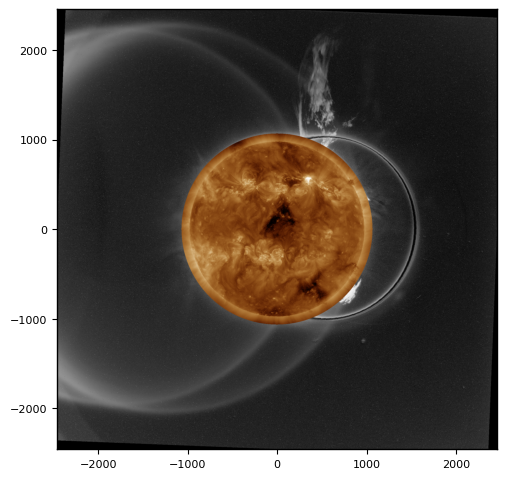

In [10]:
fig = plt.figure(figsize=(5,5))
ax = plt.axes([0.1,0.06,0.88,0.88])
ax.imshow(imout, extent=edgout)
plt.show()

### Base-Difference Intensity Composite (SunPy Map)

* **Data Combination:** We combine GOES-R/SUVI 304 Å (solar disk), ASO-S/LST/SCIUV (inner corona), and SOHO/LASCO-C2 (outer corona) across non-overlapping fields of view.
* **Colormaps & Output:** The resulting grayscale matrix retains spatial coordinate metadata and is formatted into a native `sunpy.map.Map` object for standardized solar coordinate plotting.

In [5]:
def suvi304diff(f,fbkg='D:\\solp\\FE20230224\\suvi_full\\suvi304_2023-02-24T192638.fits'):
    m304 = smap.Map(f)
    m304bkg = smap.Map(fbkg)
    im = sct.norm8(m304.data,vmin=0.1,vmax=100,log=True)
    imbkg = sct.norm8(m304bkg.data,vmin=0.1,vmax=100,log=True)
    imd = im.astype(np.int16)-imbkg.astype(np.int16)
    hdr = m304.meta
    hdr['rsun_obs'] = 969.8933149690835
    return smap.Map(imd,hdr)

In [6]:
# difference image of SUVI 304A observation on 2023-02-24
msuvi = suvi304diff('D:\\solp\\FE20230224\\suvi_full\\suvi304_2023-02-24T204819.fits')

In [7]:
fc2b = "D:\\solp\\FE20230224\\lasco\\23925647.fts"
fc2 = "D:\\solp\\FE20230224\\lasco\\23925652.fts"
# In this example, despike is necessary:
mc2 = sct.lascoMapb(fc2,fbkg=fc2b,despike=True,n_isolate=55)

 [astropy.io.fits.verify]


 [astropy.io.fits.verify]


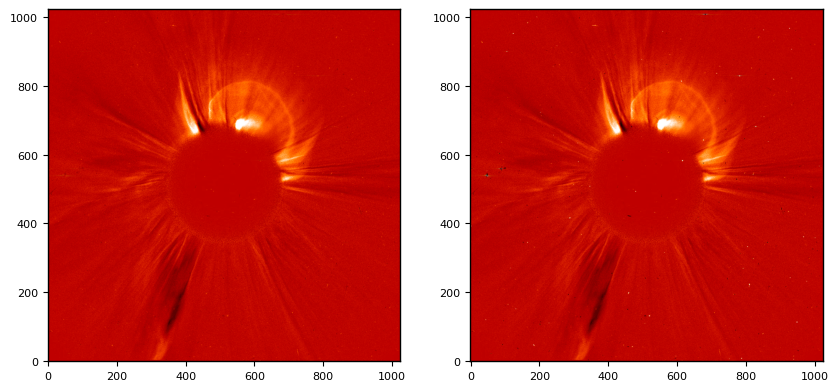

In [8]:
# Compare the despiked image with the original image
mc2a = sct.lascoMapb(fc2,fbkg=fc2b,despike=False)
fig = plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(mc2.data, vmin=-500, vmax=500)
plt.subplot(1,2,2)
plt.imshow(mc2a.data, vmin=-500, vmax=500)
plt.show()

In [9]:
# SCIUV
fsci = "D:\\solp\\FE20230224\\sci\\sciuv_long_20230224T2048.fits"
fsci_bkg = "D:\\solp\\FE20230224\\sci\\sciuv_long_20230224T2018.fits"
ima, hdra = sct.readfits(fsci)
imb, hdrb = sct.readfits(fsci_bkg)
tmp = sct.norm8(medfilt2d(ima,3),vmin=1,vmax=1500,log=True)
tmp1 = sct.norm8(medfilt2d(imb,3),vmin=1,vmax=1500,log=True)
imd = tmp.astype(np.int16)-tmp1.astype(np.int16)
# use level 1.5 AIA fits file to supply additional information for SCIUV header
faia = "D:\\solp\\FE20230224\\aia15\\AIA_193_2023-02-24T204807.fits"
maia = smap.Map(faia)
hdr = sct.scihdr(hdra, cdelt=2.4, crvals=[0,0], crpixs=[crpix1,crpix2], rotrad=rotrad, aiahdr=maia.fits_header)
msci = sct.scimap(imd, hdr)

In [10]:
# imSuviSci,edg = sct.combineDisk_lasco(msuvi, msci, vc2=[-128,128], vdisk=[-128,128], rmask=1.2)
imSuviSci,edg, hdrout = sct.combineDisk_SCI(msuvi, msci, vsci=[-128,128], vdisk=[-128,128], logsci=False, logdisk=False, rmask=1.2, scaleSCI=2.4, cmapdisk=None, cmapsci=None)
mSuviSci = smap.Map(imSuviSci, hdrout)

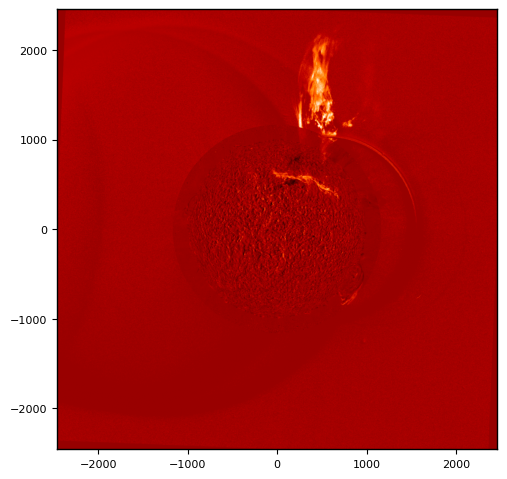

In [17]:
fig = plt.figure(figsize=(5,5))
ax = plt.axes([0.1,0.06,0.88,0.88])
ax.imshow(imSuviSci, extent=edg)
plt.show()

In [11]:
imSSC2,edg = sct.combineDisk_lasco(mSuviSci, mc2, vc2=[-1000,1000], vdisk=[0,1], rmask=2)
mssc2 = smap.Map(imSSC2, mc2.meta)

INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,dsun_obs,hgln_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crlt_obs,crln_obs
 [sunpy.map.mapbase]


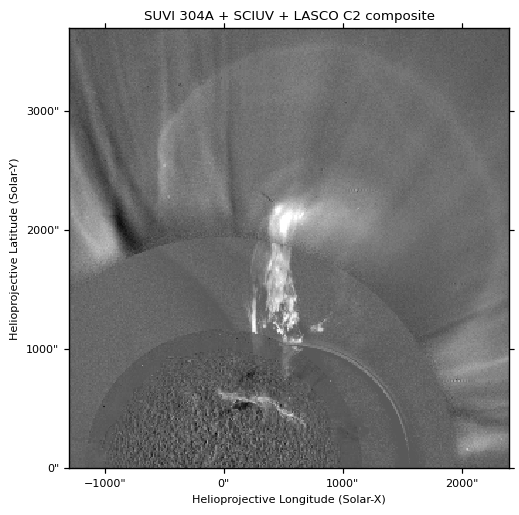

In [12]:
xlims_world = [-1300, 2400]*u.arcsec
ylims_world = [0, 3700]*u.arcsec
world_coords = SkyCoord(Tx=xlims_world, Ty=ylims_world, frame=mssc2.coordinate_frame)
pixel_coords = mssc2.world_to_pixel(world_coords)
xlims_pixel = pixel_coords.x.value
ylims_pixel = pixel_coords.y.value
mssc2.plot_settings['cmap'] = 'gray'
mssc2.plot_settings['norm'] = mcolors.Normalize(vmin=59/255.0,vmax=1)
fig = plt.figure(figsize=(5,5))
ax = plt.axes([0.1,0.06,0.88,0.88], projection=mssc2)
mssc2.plot(axes=ax, title='SUVI 304A + SCIUV + LASCO C2 composite')
ax.set_xlim(xlims_pixel)
ax.set_ylim(ylims_pixel)
ax.grid(b=False)
plt.show()

## SDI+SCIUV+C2 RGB image
Two steps: (1) gray image combining the three channels; (2) give colormap to different region.

In [5]:
from scipy.signal import  medfilt2d # median filter

In [7]:
# SDI image. 
# The SDI image has been aligned with level-1.5 AIA 304 image. The alignment code is the modified version of Kaifan Ji, so it cannot be uploaded.
with fits.open('D:\\solp\\FE20230224\\sdi_align\\sdi_lev10_20230224_204834.546_toAIA304_v01.fits.gz') as hdul:
    msdi = smap.Map(medfilt2d(hdul[1].data,3), hdul[1].header)
    m304 = smap.Map(hdul[2].data, hdul[2].header)

In [22]:
# SCIUV
fsci = "D:\\solp\\FE20230224\\sci\\sciuv_long_20230224T2048.fits"
ima, hdra = sct.readfits(fsci)
hdrsci = sct.scihdr(hdra, cdelt=2.4, crvals=[0,0], crpixs=[crpix1,crpix2], rotrad=rotrad, aiahdr=m304.fits_header)
msci = sct.scimap(medfilt2d(ima,3), hdrsci)

In [28]:
imSdiSci,edg, hdrout = sct.combineDisk_SCI(msdi, msci, vsci=[1,1500], vdisk=[10,20000], logsci=True, logdisk=True,
                                            rmask=1.1, scaleSCI=2.4, cmapdisk=None, cmapsci=None)
mSdiSci = smap.Map(imSdiSci, hdrout)

In [16]:
# C2, the background must be subtracted
fc2b = "D:\\solp\\FE20230224\\lasco\\23925647.fts"
fc2 = "D:\\solp\\FE20230224\\lasco\\23925652.fts"
# In this example, despike is necessary:
mc2 = sct.lascoMapb(fc2,fbkg=fc2b,despike=True,n_isolate=55)

 [astropy.io.fits.verify]


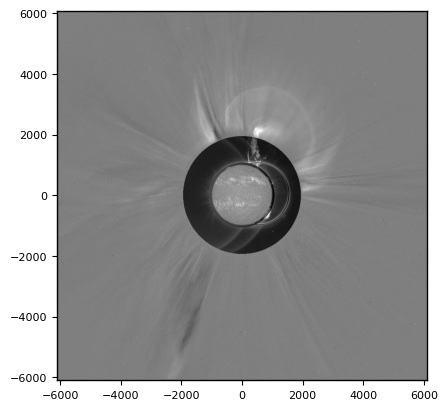

In [30]:
imSSC2,edg = sct.combineDisk_lasco(mSdiSci, mc2, vc2=[-1000,1000], vdisk=[0,1], rmask=2)
plt.imshow(imSSC2, extent=edg, cmap='gray')
plt.show()

In [31]:
# Set color-maps
dc2 = mc2.scale.axis1.value
nyc2, nxc2 = imSSC2.shape[0:2]
rr = sct.dist_circle((nxc2,nyc2),dtype=np.float32)*dc2 # heliocentric distance
# 
rmasks=[1.1,2] # boundaries
tmp = np.zeros([2,1024,1024,4]) # to contain the RGB images
msk = np.zeros([1024,1024],dtype=np.int8)
msk[rr<rmasks[-1]*rsun_obs] = 1 # keep this order. Or strict boundary (rr>rmasks[-2]*rsun_obs) and (rr<rmasks[-1]*rsun_obs)
msk[rr<rmasks[-2]*rsun_obs] = 2
#
cmaps = [plt.get_cmap('soholasco2'), plt.get_cmap('gray'), plt.get_cmap('Blues_r')] # color-maps of the three channels
imSSC2rgb = cmaps[0](imSSC2/np.max(imSSC2))
for i in range(2):
    tmp[i] = cmaps[i+1](imSSC2/np.max(imSSC2))
#
for i in range(4):
    tmpa = imSSC2rgb[:,:,i]
    for j in range(2):
        tmpb = tmp[j,:,:,i]
        tmpa[msk==j+1] = tmpb[msk==j+1]
    imSSC2rgb[:,:,i] = tmpa

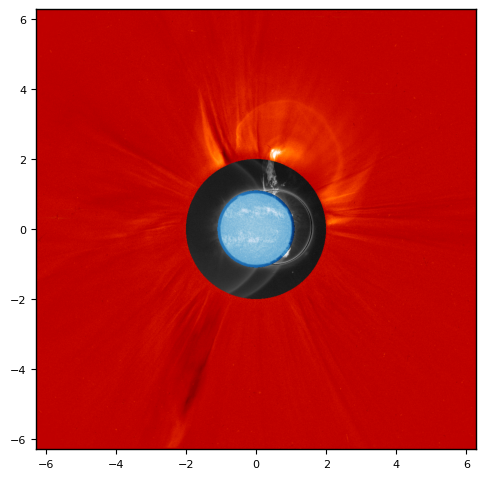

In [34]:
fig = plt.figure(figsize=(5,5))
ax = plt.axes([0.1,0.06,0.88,0.88])
ax.imshow(imSSC2rgb, extent=np.array(edg)/rsun_obs)
plt.show()